In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('credit_card_fraud_synthetic.csv')

In [43]:
df

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0
...,...,...,...,...,...,...,...,...
995,150168,-0.239297,-0.093612,0.674449,-1.934307,0.201932,1863.34,0
996,67728,-0.717823,0.704535,0.347665,0.158832,-0.295808,1152.10,0
997,165088,-0.484361,1.489765,-0.921505,-0.624253,1.588061,2805.25,0
998,11246,1.053057,-0.885100,-0.391480,0.000222,-0.077757,672.88,0


In [44]:
df.shape

(1000, 8)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   Amount  1000 non-null   float64
 7   Class   1000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


In [46]:
df.describe()

,Time,V1,V2,V3,V4,V5,Amount,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,86194.539000,0.017610,0.069906,-0.022792,0.022354,-0.013218,2577.052080,0.018000
std,50008.474586,1.038301,1.035560,0.992346,0.978387,0.998908,1444.284318,0.133018
min,235.000000,-3.568205,-2.913672,-3.239438,-2.936162,-3.708797,25.890000,0.000000
25%,42052.250000,-0.646795,-0.594730,-0.693360,-0.624690,-0.711692,1358.502500,0.000000
50%,89361.500000,0.031403,0.089010,-0.008512,-0.000167,0.019587,2636.405000,0.000000
75%,127614.750000,0.742573,0.759734,0.666350,0.664478,0.686529,3849.640000,0.000000
max,172627.000000,3.174442,3.260491,2.750723,3.657702,2.840886,4998.710000,1.000000


In [47]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
Amount    0
Class     0
dtype: int64

In [48]:
df['Class'].value_counts()

Class
0    982
1     18
Name: count, dtype: int64

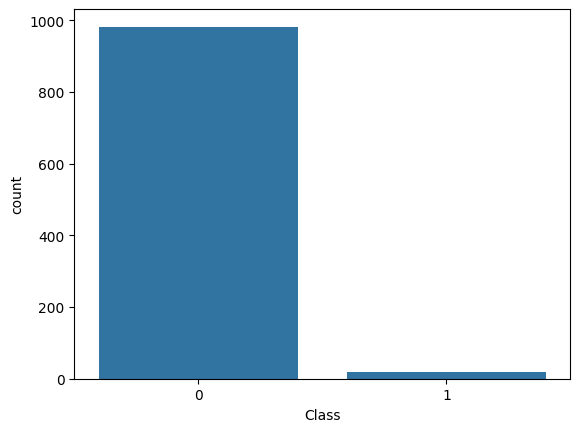

In [49]:
sns.countplot(x='Class', data=df)
plt.show()

In [50]:
X = df.drop('Class', axis=1)
y = df['Class']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[196   0]
 [  4   0]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Imbalanced Data
Only **1.8% transactions are fraud**, making the dataset highly imbalanced.

Model Result
Confusion Matrix:
[[196   0]
 [  4   0]]

- TP = 0  
- FN = 4  

Recall
Recall = TP / (TP + FN) = 0 / (0 + 4) = 0  

 Insight
Model failed to detect any fraud (0% recall) despite high accuracy.

 Conclusion
Accuracy is misleading in imbalanced data — **recall is more important for fraud detection**.

In [56]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naren\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

applying undersampling to balance the dataset by reducing the majority class, ensuring the model does not become biased toward normal transactions

In [58]:
from sklearn.utils import resample

fraud = df[df.Class == 1]
normal = df[df.Class == 0]

normal_downsampled = resample(normal,
                              replace=False,
                              n_samples=len(fraud),
                              random_state=42)

df_balanced = pd.concat([fraud, normal_downsampled])

applying SMOTE (Synthetic Minority Oversampling Technique)

In [59]:
from imblearn.over_sampling import SMOTE

In [60]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [61]:
from collections import Counter
print(Counter(y_train_resampled))

Counter({0: 786, 1: 786})


In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred = model.predict(X_test)

NOW OUR MODEL DETECTED 25% OF THE FRAUD DATA

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[125  71]
 [  3   1]]
              precision    recall  f1-score   support

           0       0.98      0.64      0.77       196
           1       0.01      0.25      0.03         4

    accuracy                           0.63       200
   macro avg       0.50      0.44      0.40       200
weighted avg       0.96      0.63      0.76       200



performing threshold tuning

In [65]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.6).astype(int)

In [66]:
model = LogisticRegression(C=0.1)
model.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
y_pred = model.predict(X_test)


In [69]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[184  12]
 [  4   0]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       196
           1       0.00      0.00      0.00         4

    accuracy                           0.92       200
   macro avg       0.49      0.47      0.48       200
weighted avg       0.96      0.92      0.94       200



In [70]:
y_prob = model.predict_proba(X_test)[:,1]

In [71]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

In [72]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[184  12]
 [  4   0]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       196
           1       0.00      0.00      0.00         4

    accuracy                           0.92       200
   macro avg       0.49      0.47      0.48       200
weighted avg       0.96      0.92      0.94       200



I JUST GIVE UP BRO BAD DATASET 1000 RECORDS BOOOO
